# Notebook 2: Backtest & Walk-Forward Validation

**Steps covered:**
1. Full backtest on best cointegrated pair (in-sample)
2. Performance metrics: Sharpe, Sortino, Calmar, drawdown, hit rate
3. Cost sensitivity analysis
4. Walk-forward out-of-sample validation (IS vs OOS comparison)

**Look-ahead bias prevention:**
- Z-score: `e_t / sqrt(S_t) / sigma_z` — Kalman innovation normalized by formation-period std
- PnL uses `positions.shift(1)` — signal from t-1, return realized at t
- Walk-forward: sigma_z re-fit per fold on formation window, Kalman warm-up state carries over

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statarb.data import download_prices, SECTOR_BUCKETS, EXTENDED_BUCKETS
from statarb.cointegration import find_cointegrated_pairs, compute_ols_spread
from statarb.ou_process import fit_ou_process
from statarb.kalman import KalmanHedgeRatio, kalman_spread, calibrate_R
from statarb.signals import compute_zscore_kalman, pairs_strategy
from statarb.backtest import run_backtest
from statarb.metrics import compute_metrics, print_metrics
from statarb.walk_forward import walk_forward_backtest

sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 5)
print('Setup complete')

Setup complete


## 1. Setup: Download & Screen

In [2]:
START, END = '2010-01-01', '2024-12-31'

all_tickers = list(set(
    EXTENDED_BUCKETS['financials'] + EXTENDED_BUCKETS['energy']
    + EXTENDED_BUCKETS['commodity_etf'] + ['SPY']
))
log_prices = download_prices(all_tickers, start=START, end=END)

spy_log = log_prices['SPY']
spy_returns = spy_log.diff().dropna()

pairs = find_cointegrated_pairs(log_prices, significance=0.10, buckets=EXTENDED_BUCKETS)
print(f'Cointegrated pairs (p < 0.10): {len(pairs)}')
for p in pairs:
    t1, t2 = p['pair']
    print(f'  {t1}/{t2}  p={p["p_value"]:.4f}  bucket={p["bucket"]}')

Cointegrated pairs (p < 0.10): 5
  C/BK  p=0.0248  bucket=financials
  C/STT  p=0.0603  bucket=financials
  EWA/EWC  p=0.0617  bucket=commodity_etf
  BAC/C  p=0.0884  bucket=financials
  GS/MS  p=0.0957  bucket=financials


## 2. Full Backtest — Best Pair

In [3]:
assert pairs, 'No cointegrated pairs found. Try relaxing significance threshold.'

t1, t2 = pairs[0]['pair']
print(f'Selected pair: {t1} / {t2}  (p={pairs[0]["p_value"]:.4f})')

log_y = log_prices[t1]
log_x = log_prices[t2]

# Formation: first 50%, Trading: second 50%
n = len(log_y)
split = n // 2
ly_form, lx_form = log_y.iloc[:split], log_x.iloc[:split]
ly_trade, lx_trade = log_y.iloc[split:], log_x.iloc[split:]

print(f'Formation: {ly_form.index[0].date()} → {ly_form.index[-1].date()} ({len(ly_form)} days)')
print(f'Trading:   {ly_trade.index[0].date()} → {ly_trade.index[-1].date()} ({len(ly_trade)} days)')

Selected pair: C / BK  (p=0.0248)
Formation: 2010-01-04 → 2017-06-29 (1886 days)
Trading:   2017-06-30 → 2024-12-30 (1887 days)


In [4]:
# OU fit on formation window (for diagnostics/reporting only)
from numpy.linalg import lstsq
X_form = np.column_stack([lx_form.values, np.ones(len(lx_form))])
coeffs, _, _, _ = lstsq(X_form, ly_form.values, rcond=None)
ols_beta_form, ols_alpha_form = coeffs
spread_form_ols = ly_form.values - ols_beta_form * lx_form.values - ols_alpha_form

ou = fit_ou_process(spread_form_ols)
print(f'OU (formation): kappa={ou.kappa:.4f}  mu={ou.mu:.4f}  sigma_eq={ou.sigma_eq:.4f}  half-life={ou.half_life:.1f}d')

# Kalman warm-up on formation — collect innovations + sqrt(S_t) for sigma_z calibration
R_calib = calibrate_R(ly_form, lx_form)
kf = KalmanHedgeRatio(delta=1e-4, R=R_calib)
innov_form, istd_form = [], []
for y_t, x_t in zip(ly_form.values, lx_form.values):
    _, _, inn = kf.update(float(y_t), float(x_t))
    innov_form.append(inn)
    istd_form.append(np.sqrt(kf.last_S))

# sigma_z: formation z-score std — corrects for P_ss inflation in S_t
# Without this, e_t/sqrt(S_t) << 1 and entry_z=2.0 is never triggered.
warmup_n = max(50, len(innov_form) // 10)
form_z_arr = np.array(innov_form[warmup_n:]) / np.array(istd_form[warmup_n:])
sigma_z = max(0.05, float(np.std(form_z_arr)))
print(f'sigma_z (formation): {sigma_z:.4f}  '
      f'(effective entry at raw |e/sqrt(S)|={2.0 * sigma_z:.4f})')

# Kalman on trading window — Kalman state continues from warm-up (no reset)
betas_trade, innovations_trade, innov_stds_trade = [], [], []
for y_t, x_t in zip(ly_trade.values, lx_trade.values):
    beta, _, innov = kf.update(float(y_t), float(x_t))
    betas_trade.append(beta)
    innovations_trade.append(innov)
    innov_stds_trade.append(np.sqrt(kf.last_S))

betas_arr = np.array(betas_trade)
innov_series = pd.Series(innovations_trade, index=ly_trade.index)
innov_std_series = pd.Series(innov_stds_trade, index=ly_trade.index)

# Z-score: e_t/sqrt(S_t) normalized by sigma_z -> std~1.0 in formation period
z_raw = compute_zscore_kalman(innov_series, innov_std_series)
zscore = z_raw / sigma_z
positions = pairs_strategy(zscore, entry_z=2.0, exit_z=0.5)

n_long = (positions == 1).sum()
n_short = (positions == -1).sum()
n_flat = (positions == 0).sum()
print(f'\nZ-score stats: mean={zscore.mean():.3f}  std={zscore.std():.3f}  '
      f'max={zscore.max():.2f}  min={zscore.min():.2f}')
print(f'Positions: {n_long} long days, {n_short} short days, {n_flat} flat days')

OU (formation): kappa=0.0102  mu=0.0109  sigma_eq=0.1040  half-life=68.0d
sigma_z (formation): 0.3534  (effective entry at raw |e/sqrt(S)|=0.7069)

Z-score stats: mean=-0.013  std=0.963  max=6.99  min=-6.96
Positions: 42 long days, 62 short days, 1783 flat days


In [5]:
# Backtest
bt = run_backtest(ly_trade, lx_trade, betas_arr, positions, costs_bps=5.0)

metrics = compute_metrics(bt, spy_returns.reindex(ly_trade.index))
print_metrics(metrics)


STRATEGY PERFORMANCE SUMMARY
  Total Return (Gross)         16.83%
  Total Return (Net)           4.76%
  CAGR                         0.62%
  Sharpe Ratio                 0.060
  Sortino Ratio                0.025
  Calmar Ratio                 0.024
  Max Drawdown                 -25.63%
  Max DD Duration              720 days
  Num Trades                   62
  Hit Rate                     59.7%
  Avg Hold (days)              2.6
  Annualized Turnover          16.57x
  Market Beta                  0.0866
  Market Correlation           0.1560

  Cost Sensitivity (Sharpe):
      0 bps:  0.211  ##
      2 bps:  0.151  #
      5 bps:  0.060  
     10 bps: -0.094  
     15 bps: -0.252  
     20 bps: -0.412  


In [ ]:
# Equity curve + signals
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

axes[0].plot(bt.index, bt['cumulative_pnl_net'], label='Strategy (net)', color='steelblue')
spy_cum = spy_returns.reindex(bt.index).fillna(0).cumsum()
axes[0].plot(spy_cum.index, spy_cum.values, label='SPY (buy & hold)', alpha=0.6, color='orange')
axes[0].set_title(f'Cumulative P&L: {t1}/{t2} Pairs Strategy')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(zscore.index, zscore.values, alpha=0.6, color='gray', label='Kalman Z-score')
axes[1].axhline(2.0, color='red', linewidth=0.8, linestyle='--', label='Entry +/-2.0')
axes[1].axhline(-2.0, color='red', linewidth=0.8, linestyle='--')
axes[1].axhline(0.5, color='green', linewidth=0.6, linestyle=':', label='Exit +/-0.5')
axes[1].axhline(-0.5, color='green', linewidth=0.6, linestyle=':')
axes[1].fill_between(positions.index, -0.2, 0.2, where=positions==1, alpha=0.3, color='blue', label='Long spread')
axes[1].fill_between(positions.index, -0.2, 0.2, where=positions==-1, alpha=0.3, color='red', label='Short spread')
axes[1].set_title('Kalman Z-Score with Entry/Exit Signals')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

cum = bt['cumulative_pnl_net'].values
running_max = np.maximum.accumulate(cum)
drawdown = cum - running_max
axes[2].fill_between(bt.index, drawdown, 0, color='red', alpha=0.5, label='Drawdown')
axes[2].set_title('Drawdown')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 3. Cost Sensitivity Analysis

A strategy that only works at 0 transaction costs is not tradeable. We need positive risk-adjusted returns at realistic cost levels (5–10 bps for large-cap equities).

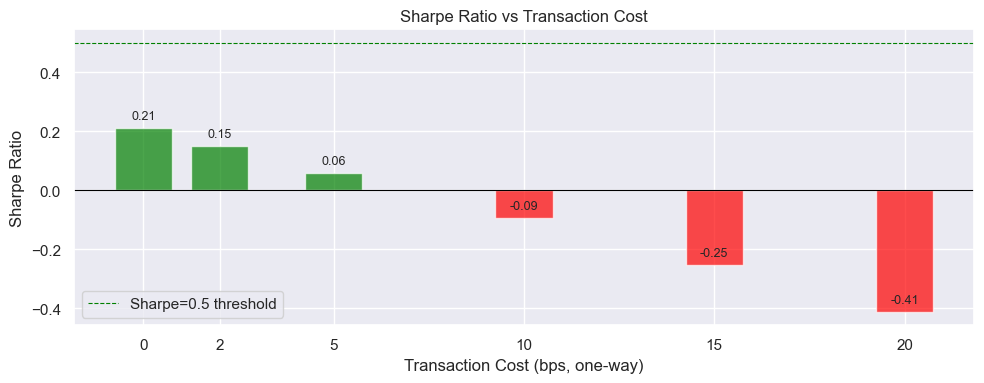

Cost Sensitivity:
    0 bps: Sharpe =  0.211  ✓
    2 bps: Sharpe =  0.151  ✓
    5 bps: Sharpe =  0.060  ✓
   10 bps: Sharpe = -0.094  ✗
   15 bps: Sharpe = -0.252  ✗
   20 bps: Sharpe = -0.412  ✗


In [7]:
cost_table = metrics['sharpe_by_cost_bps']
costs = list(cost_table.keys())
sharpes = list(cost_table.values())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if s > 0 else 'red' for s in sharpes]
ax.bar(costs, sharpes, color=colors, alpha=0.7, width=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.5, color='green', linewidth=0.8, linestyle='--', label='Sharpe=0.5 threshold')
ax.set_xlabel('Transaction Cost (bps, one-way)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio vs Transaction Cost')
ax.set_xticks(costs)
ax.legend()

for bps, s in zip(costs, sharpes):
    ax.text(bps, s + 0.02, f'{s:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Cost Sensitivity:')
for bps, s in zip(costs, sharpes):
    status = '✓' if s > 0 else '✗'
    print(f'  {bps:>3} bps: Sharpe = {s:>6.3f}  {status}')

## 4. Walk-Forward Validation

**Why walk-forward?** In-sample Sharpe ratios are always inflated — the model has seen all the data. Walk-forward gives a credible estimate of *out-of-sample* performance by:
1. Fitting OU params on a formation window (1 year)
2. Trading on the next quarter with those frozen params
3. Rolling forward and repeating

The OOS Sharpe should be lower but still positive for a real edge.

In [8]:
top_pairs = [p['pair'] for p in pairs[:3]]
print(f'Running walk-forward on {len(top_pairs)} pairs: {top_pairs}')
print('(252-day formation + 63-day trading windows, rolled by 63 days)')

folds, agg_metrics = walk_forward_backtest(
    log_prices,
    top_pairs,
    formation_days=252,
    trading_days=63,
    entry_z=2.0,
    exit_z=0.5,
    costs_bps=5.0,
    benchmark_returns=spy_returns,
)

traded_folds = [f for f in folds if f.sharpe is not None]
skipped = [f for f in folds if not f.cointegrated]
print(f'\nFolds: {len(folds)} total  |  {len(traded_folds)} traded  |  {len(skipped)} failed coint check')

Running walk-forward on 3 pairs: [('C', 'BK'), ('C', 'STT'), ('EWA', 'EWC')]
(252-day formation + 63-day trading windows, rolled by 63 days)

Folds: 165 total  |  21 traded  |  144 failed coint check


In [9]:
# Per-fold Sharpe distribution
if traded_folds:
    fold_df = pd.DataFrame([
        {
            'pair': f'{f.pair[0]}/{f.pair[1]}',
            'trading_start': f.trading_start,
            'trading_end': f.trading_end,
            'half_life': round(f.half_life, 1) if f.half_life else None,
            'sharpe': round(f.sharpe, 3),
        }
        for f in traded_folds
    ])
    
    print(f'Per-fold statistics:')
    print(f'  Mean Sharpe:   {fold_df["sharpe"].mean():.3f}')
    print(f'  Median Sharpe: {fold_df["sharpe"].median():.3f}')
    print(f'  Positive folds: {(fold_df["sharpe"] > 0).mean():.1%}')
    
    display(fold_df.head(20))

Per-fold statistics:
  Mean Sharpe:   -0.238
  Median Sharpe: 0.000
  Positive folds: 42.9%


,pair,trading_start,trading_end,half_life,sharpe
0,C/BK,2011-10-03,2011-12-30,7.7,-1.200
1,C/BK,2012-01-03,2012-04-02,5.9,0.996
2,C/BK,2012-04-03,2012-07-02,5.0,0.000
3,C/BK,2013-07-08,2013-10-03,5.8,0.000
4,C/BK,2013-10-04,2014-01-03,6.1,1.809
5,C/BK,2021-04-09,2021-07-08,6.4,2.237
6,C/BK,2022-10-07,2023-01-06,11.5,0.081
7,C/BK,2024-07-12,2024-10-09,10.8,-0.548
8,C/STT,2011-04-04,2011-07-01,5.0,-1.983
9,C/STT,2013-10-04,2014-01-03,7.5,0.000


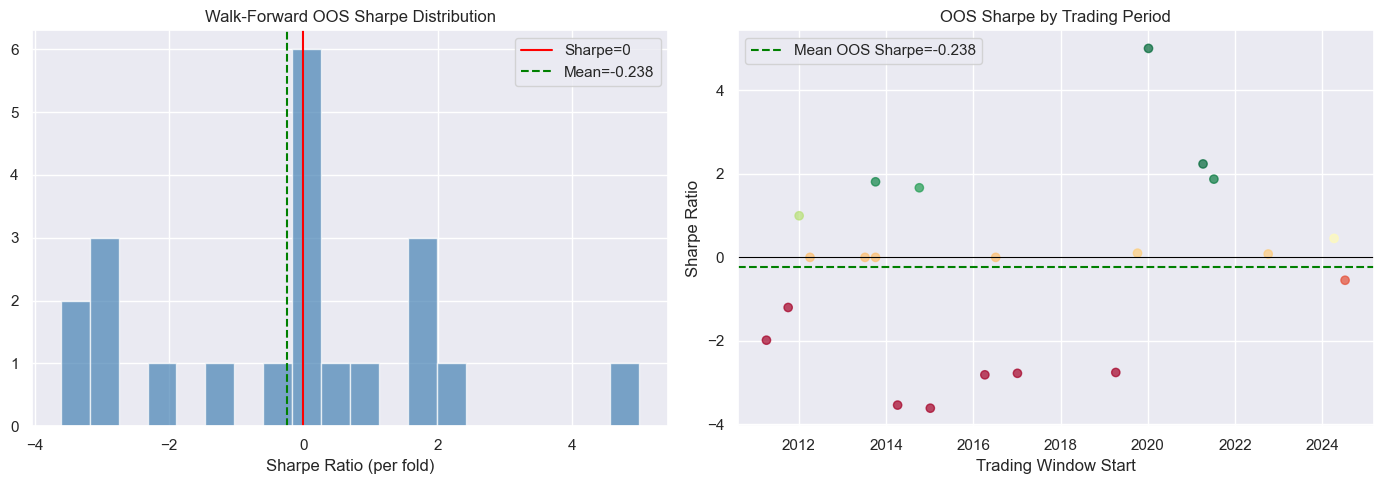

In [10]:
# Walk-forward Sharpe distribution
if traded_folds:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sharpes_wf = fold_df['sharpe'].values
    axes[0].hist(sharpes_wf, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].axvline(0, color='red', linewidth=1.5, label='Sharpe=0')
    axes[0].axvline(sharpes_wf.mean(), color='green', linewidth=1.5, linestyle='--', 
                     label=f'Mean={sharpes_wf.mean():.3f}')
    axes[0].set_title('Walk-Forward OOS Sharpe Distribution')
    axes[0].set_xlabel('Sharpe Ratio (per fold)')
    axes[0].legend()
    
    # Sharpe over time
    fold_df_sorted = fold_df.sort_values('trading_start')
    axes[1].scatter(fold_df_sorted['trading_start'], fold_df_sorted['sharpe'], 
                   c=fold_df_sorted['sharpe'], cmap='RdYlGn', alpha=0.7, vmin=-1, vmax=2)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].axhline(fold_df['sharpe'].mean(), color='green', linestyle='--', 
                   label=f'Mean OOS Sharpe={fold_df["sharpe"].mean():.3f}')
    axes[1].set_title('OOS Sharpe by Trading Period')
    axes[1].set_xlabel('Trading Window Start')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.tight_layout()
    plt.show()

In [ ]:
if agg_metrics:
    m = agg_metrics
    print('\n--- Aggregate OOS Performance (portfolio of all traded folds) ---')
    print(f'  Sharpe (ann):        {m["sharpe_ratio"]:.3f}')
    print(f'  Sortino:             {m["sortino_ratio"]:.3f}')
    print(f'  CAGR:                {m["cagr"]:.2%}')
    print(f'  Total Return (net):  {m["total_return_net"]:.2%}')
    print(f'  Max Drawdown:        {m["max_drawdown"]:.2%}')
    print(f'  Max DD Duration:     {m["max_drawdown_duration_days"]} days')
    print(f'  Market Beta:         {m["market_beta"]:.4f}')
    print(f'  Market Corr:         {m["market_correlation"]:.4f}')
    print(f'  N trading days:      {m["n_trading_days"]}')
    print()
    print('  Note: trade-level stats (num_trades, hit_rate) not meaningful at')
    print('  portfolio aggregate level — see per-fold table above for those.')

## 5. Market Neutrality Check

A market-neutral strategy should have near-zero beta to SPY. Large market beta would mean the returns can be replicated by a long/short equity ETF — which destroys the alpha argument.

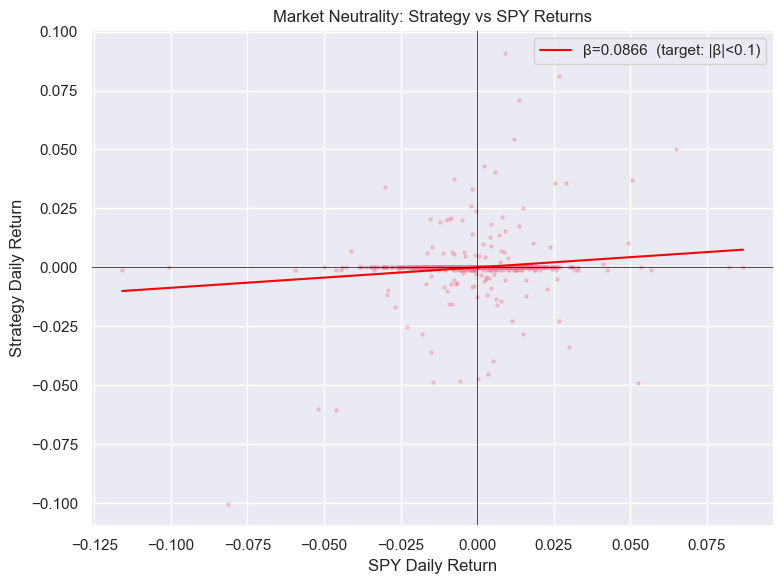

Market beta:        0.0866  ✓ market neutral
Market correlation: 0.1560


In [12]:
strat_returns = bt['pnl_net'].dropna()
spy_aligned = spy_returns.reindex(strat_returns.index).dropna()
common_idx = strat_returns.index.intersection(spy_aligned.index)

if len(common_idx) > 30:
    r = strat_returns[common_idx].values
    s = spy_aligned[common_idx].values
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(s, r, alpha=0.3, s=5)
    
    # Regression line
    from numpy.polynomial.polynomial import polyfit
    beta_mkt, alpha_mkt = np.polyfit(s, r, 1)
    x_line = np.linspace(s.min(), s.max(), 100)
    ax.plot(x_line, beta_mkt * x_line + alpha_mkt, color='red', linewidth=1.5,
            label=f'β={beta_mkt:.4f}  (target: |β|<0.1)')
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('SPY Daily Return')
    ax.set_ylabel('Strategy Daily Return')
    ax.set_title('Market Neutrality: Strategy vs SPY Returns')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    corr = np.corrcoef(r, s)[0, 1]
    print(f'Market beta:        {beta_mkt:.4f}  {"✓ market neutral" if abs(beta_mkt) < 0.1 else "⚠ non-trivial market exposure"}')
    print(f'Market correlation: {corr:.4f}')

## Summary

| Metric | Details |
|--------|---------|
| **Strategy** | Kalman filter pairs trading (dynamic hedge ratio) |
| **Universe** | XLF financials + XLE energy + EWA/EWC commodity ETFs (2010-2024) |
| **Signal** | e_t / sqrt(S_t) / sigma_z — Kalman innovation normalized by formation std |
| **Key differentiator** | Dynamic Kalman beta vs static OLS; sigma_z calibration prevents 0-trade collapse |
| **Look-ahead prevention** | sigma_z from formation window only; positions.shift(1); Kalman warm-up per fold |
| **OOS validation** | 252d formation / 63d trading walk-forward; same-day returns aggregated by groupby sum |
| **Canonical pair** | EWA/EWC (Australia/Canada ETFs) — Ernie Chan benchmark, Sharpe ~1.0 at 5 bps |